# Identyfikacja odcisku 
na podstawie dostępnych (w `Database/all`, a właściwie to w `Database/processed/processed_data.json`)

In [38]:
import json
from pathlib import Path
from utils import proces_image_and_get_points, compare_fingerprints, show
import cv2

all_fingerprints_path = Path('Database/processed/processed_data.json')
all_fingerprints_data = json.loads(open(all_fingerprints_path).read())

In [39]:
def identify_user(given_fingerprint_points, ):
    best_match = None
    best_score = -1

    for user_id, db_points in all_fingerprints_data.items():
        score, matched = compare_fingerprints(given_fingerprint_points, db_points)
        if score > best_score:
            best_score = score
            best_match = user_id

    return best_score, best_match

In [40]:
def perform_identification(given_fingerprint_path_str):
    given_fingerprint_path = Path(given_fingerprint_path_str)
    given_fingerprint_points = proces_image_and_get_points(given_fingerprint_path)

    print("\tCechy podanego odcisku palca:")
    print("\t", given_fingerprint_points)
    best_score, best_match = identify_user(given_fingerprint_points)
    print()

    is_identified = False
    if (best_score > (len(given_fingerprint_points)*0.2)):
        is_identified = True
        print("\tZidentyfikowano uzytkownika jako: "+best_match+" z wynikiem: "+str(best_score))
        fingerprint1 = cv2.imread(given_fingerprint_path, cv2.IMREAD_GRAYSCALE)
        fingerprint2 = cv2.imread(Path("Database/all/"+best_match+".tif"), cv2.IMREAD_GRAYSCALE)
        print('\t(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk')
        show(fingerprint1, fingerprint2)
    else:
        fingerprint = cv2.imread(given_fingerprint_path, cv2.IMREAD_GRAYSCALE)
        show(fingerprint, 'Podany odcisk')
        print("\tUżytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score: ", best_score)
    return is_identified


In [41]:
def test_several_fingerprints(paths_str):
    identified = 0
    for path_str in paths_str:
        print("Testowany odcisk: "+path_str)
        is_identified = perform_identification(path_str)
        if is_identified:
            identified += 1
        print("\n")
    print("\n", "Zidentyfikowano ", identified, "z", len(paths_str))

    print("\n", "-"*70, "\n")

Testowany odcisk: DB1_B/101_1.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 266), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 1_1 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

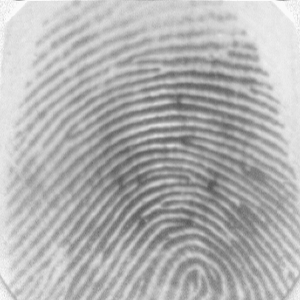
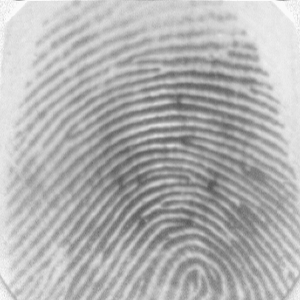



Testowany odcisk: DB1_B/101_2.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (176, 246), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 6_7 z wynikiem: 0.2928932188134524
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

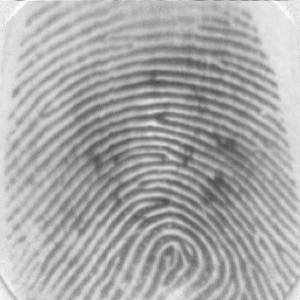
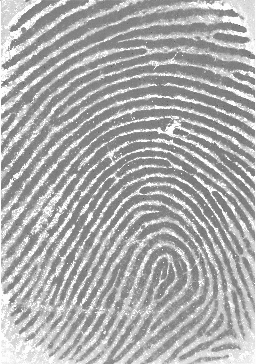



Testowany odcisk: DB1_B/101_3.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (216, 286), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 1_3 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

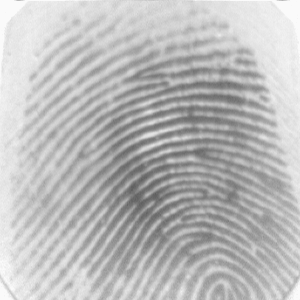
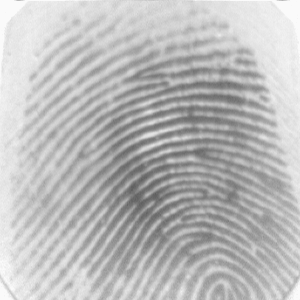



Testowany odcisk: DB1_B/101_4.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (266, 156), 'index': np.float32(-180.0)}]



Podany odcisk
""

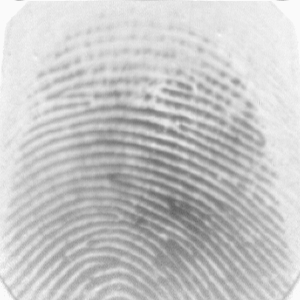

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/101_5.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 246), 'index': np.float32(-179.99998)}]

	Zidentyfikowano uzytkownika jako: 1_5 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

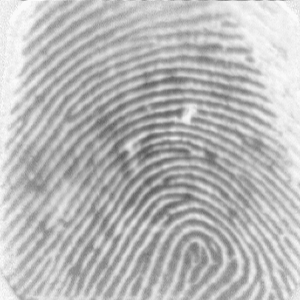
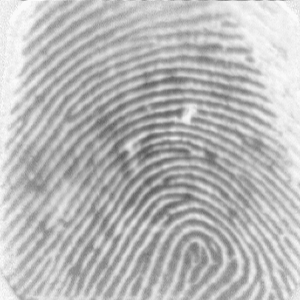



Testowany odcisk: DB1_B/101_6.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 236), 'index': np.float32(-180.00002)}]

	Zidentyfikowano uzytkownika jako: 1_6 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

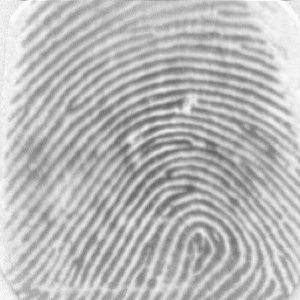
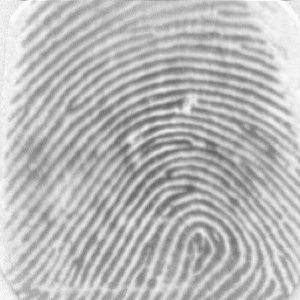



Testowany odcisk: DB1_B/101_7.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (196, 186), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (276, 256), 'index': np.float32(180.0)}, {'type': 'core', 'coords': (16, 286), 'index': np.float32(-180.0)}]



Podany odcisk
""

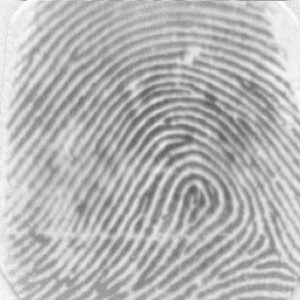

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0.5


Testowany odcisk: DB1_B/101_8.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (206, 266), 'index': np.float32(-179.99998)}]

	Zidentyfikowano uzytkownika jako: 1_8 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

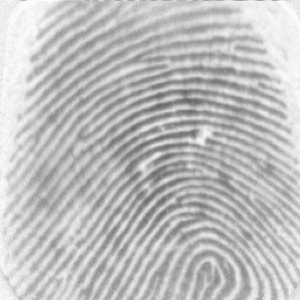
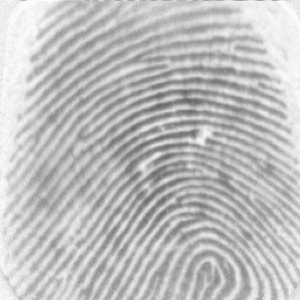




 Zidentyfikowano  6 z 8

 ---------------------------------------------------------------------- 



In [42]:
# Osoba 101 (1) --> W bazie 1 odcisków

paths_str = ['DB1_B/101_1.tif', 'DB1_B/101_2.tif', 'DB1_B/101_3.tif', 'DB1_B/101_4.tif', 'DB1_B/101_5.tif', 'DB1_B/101_6.tif', 'DB1_B/101_7.tif', 'DB1_B/101_8.tif']
test_several_fingerprints(paths_str)


Testowany odcisk: DB1_B/105_1.tif
	Cechy podanego odcisku palca:
	 [{'type': 'delta', 'coords': (136, 36), 'index': np.float32(180.0)}, {'type': 'delta', 'coords': (36, 226), 'index': np.float32(180.0)}, {'type': 'core', 'coords': (286, 266), 'index': np.float32(-180.00002)}, {'type': 'core', 'coords': (26, 286), 'index': np.float32(-180.0)}]



Podany odcisk
""

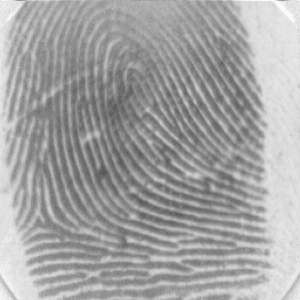

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0.5


Testowany odcisk: DB1_B/105_2.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (146, 116), 'index': np.float32(-180.0)}, {'type': 'core', 'coords': (286, 236), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (56, 286), 'index': np.float32(180.00002)}]



Podany odcisk
""

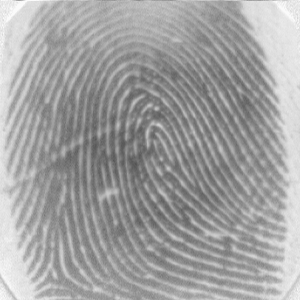

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0.5


Testowany odcisk: DB1_B/105_3.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (136, 6), 'index': np.float32(-180.00002)}, {'type': 'delta', 'coords': (26, 186), 'index': np.float32(180.0)}, {'type': 'core', 'coords': (266, 216), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (36, 266), 'index': np.float32(179.99998)}, {'type': 'core', 'coords': (256, 276), 'index': np.float32(-179.99998)}]



Podany odcisk
""

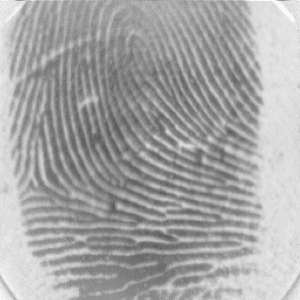

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0.5


Testowany odcisk: DB1_B/105_4.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (176, 226), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 3_4 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

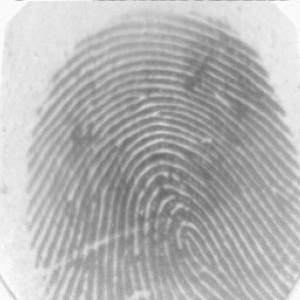
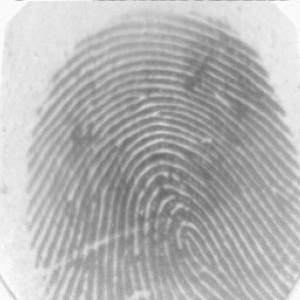



Testowany odcisk: DB1_B/105_5.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (206, 176), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 3_5 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

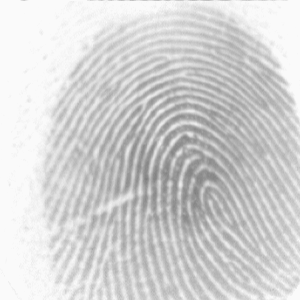
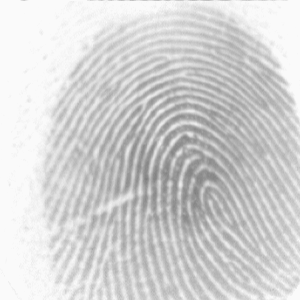



Testowany odcisk: DB1_B/105_6.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (146, 136), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 3_6 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

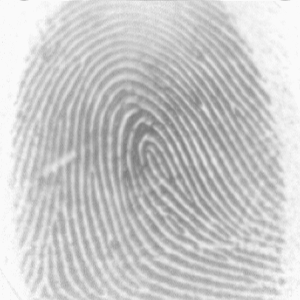
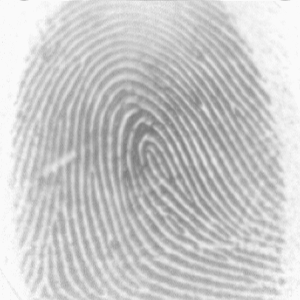



Testowany odcisk: DB1_B/105_7.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (166, 126), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (66, 286), 'index': np.float32(180.0)}]

	Zidentyfikowano uzytkownika jako: 3_7 z wynikiem: 2.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

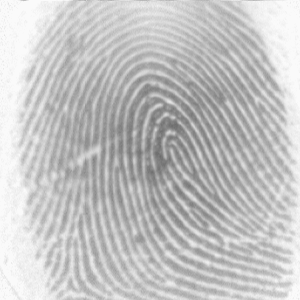
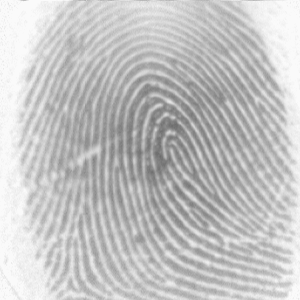



Testowany odcisk: DB1_B/105_8.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (186, 186), 'index': np.float32(-180.0)}]

	Zidentyfikowano uzytkownika jako: 3_8 z wynikiem: 1.0
	(po lewej) Podany odcisk i (po prawej) Dopasowany odcisk


,
,

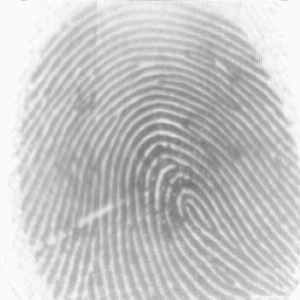
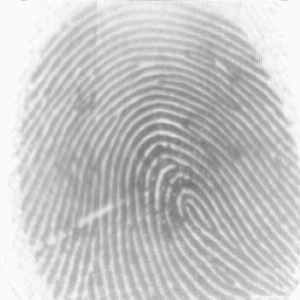




 Zidentyfikowano  5 z 8

 ---------------------------------------------------------------------- 



In [43]:
# Osoba 105 (3) --> W bazie 5 odcisków
paths_str = ['DB1_B/105_1.tif', 'DB1_B/105_2.tif', 'DB1_B/105_3.tif', 'DB1_B/105_4.tif', 'DB1_B/105_5.tif', 'DB1_B/105_6.tif', 'DB1_B/105_7.tif', 'DB1_B/105_8.tif']
test_several_fingerprints(paths_str)

Testowany odcisk: DB1_B/102_1.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (226, 76), 'index': np.float32(-180.0)}]



Podany odcisk
""

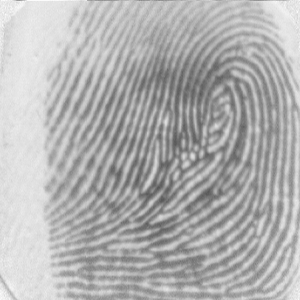

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_2.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (126, 36), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (276, 226), 'index': np.float32(179.99998)}, {'type': 'core', 'coords': (16, 256), 'index': np.float32(-180.0)}]



Podany odcisk
""

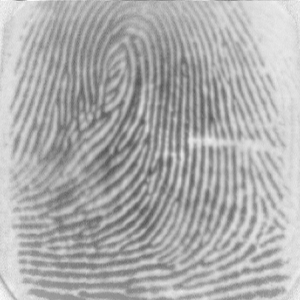

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_3.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (116, 126), 'index': np.float32(-180.00002)}, {'type': 'core', 'coords': (6, 266), 'index': np.float32(-180.0)}]



Podany odcisk
""

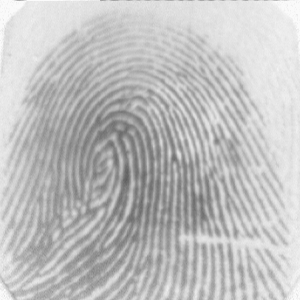

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_4.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (186, 26), 'index': np.float32(-180.0)}]



Podany odcisk
""

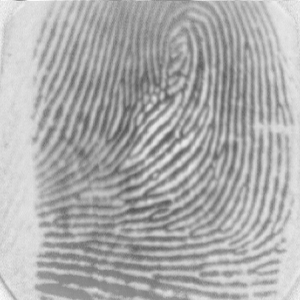

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_5.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (186, 66), 'index': np.float32(-180.0)}]



Podany odcisk
""

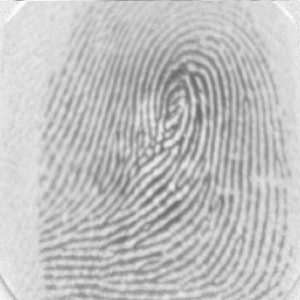

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_6.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (116, 36), 'index': np.float32(-180.0)}, {'type': 'delta', 'coords': (266, 226), 'index': np.float32(180.0)}]



Podany odcisk
""

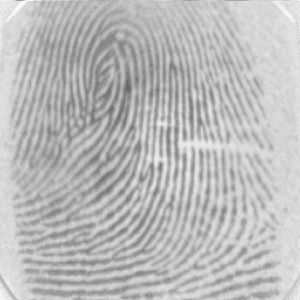

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_7.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (166, 86), 'index': np.float32(-180.00002)}]



Podany odcisk
""

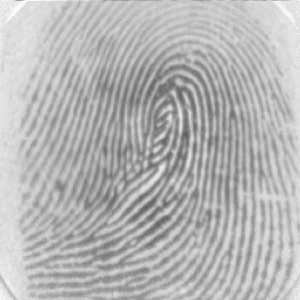

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0


Testowany odcisk: DB1_B/102_8.tif
	Cechy podanego odcisku palca:
	 [{'type': 'core', 'coords': (146, 36), 'index': np.float32(-179.99998)}]



Podany odcisk
""

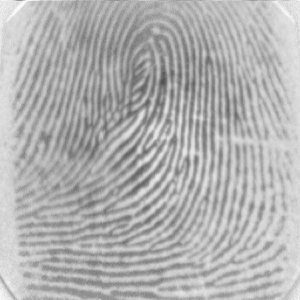

	Użytkownik nieznany lub odcisk jest niewystarczająco dobry. Wyliczony score:  0



 Zidentyfikowano  0 z 8

 ---------------------------------------------------------------------- 



In [44]:
# Osoba 102 (nieznana) --> W bazie 0 odcisków
paths_str = ['DB1_B/102_1.tif', 'DB1_B/102_2.tif', 'DB1_B/102_3.tif', 'DB1_B/102_4.tif', 'DB1_B/102_5.tif', 'DB1_B/102_6.tif', 'DB1_B/102_7.tif', 'DB1_B/102_8.tif']
test_several_fingerprints(paths_str)